## Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Starting by  fetching the data

In [3]:
# Importing All the Tables 
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_product_category = pd.read_csv('product_category_name_translation.csv')
df_sellers = pd.read_csv('olist_sellers_dataset.csv')
df_order_items = pd.read_csv('olist_order_items_dataset.csv')
df_geolocation = pd.read_csv('olist_geolocation_dataset.csv')
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_payment = pd.read_csv('olist_order_payments_dataset.csv')

df_customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [5]:
df_customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [6]:
df_customers.describe(include = 'all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [7]:
df_customers['customer_zip_code_prefix'].nunique()

14994

In [8]:
df_customers['customer_city'].nunique()

4119

1. Total unique state = 27
2. Total Unique City = 4119

In [9]:
top_states = df_customers['customer_state'].value_counts().reset_index().head(10)

In [10]:
top_states

,customer_state,count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


<Axes: xlabel='customer_state'>

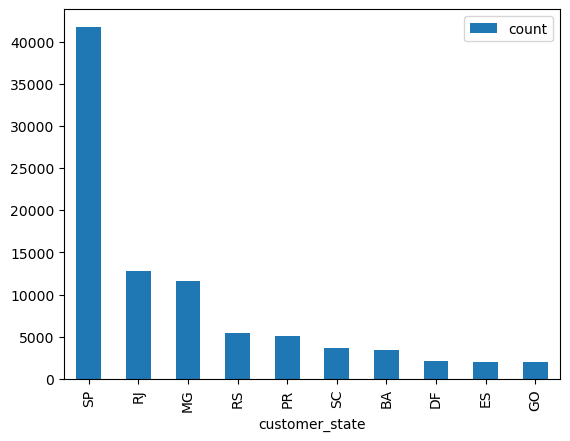

In [11]:
top_states.plot(kind = 'bar', x = 'customer_state')

TOP 5 PERFORMING CITIES OF TOP 10 PERFORMING STATES
TOP PERFORMING STATES ARE :

1. SP
2. RJ
3. MG
4. RS
5. RR
6. SC
7. BA
8. DF
9. ES
10. GO






SP

customer_city
sao paulo                15540
campinas                  1444
guarulhos                 1189
sao bernardo do campo      938
santo andre                796
Name: count, dtype: int64



RJ

customer_city
rio de janeiro     6882
niteroi             849
nova iguacu         442
sao goncalo         409
duque de caxias     266
Name: count, dtype: int64



MG

customer_city
belo horizonte    2773
juiz de fora       427
contagem           426
uberlandia         374
montes claros      211
Name: count, dtype: int64



RS

customer_city
porto alegre     1379
caxias do sul     224
canoas            210
santa maria       194
pelotas           186
Name: count, dtype: int64



PR

customer_city
curitiba        1521
londrina         306
maringa          271
cascavel         148
ponta grossa     143
Name: count, dtype: int64



SC

customer_city
florianopolis    570
joinville        264
blumenau         188
sao jose         169
itajai           120
Name: count, dtype: int64



BA

cus

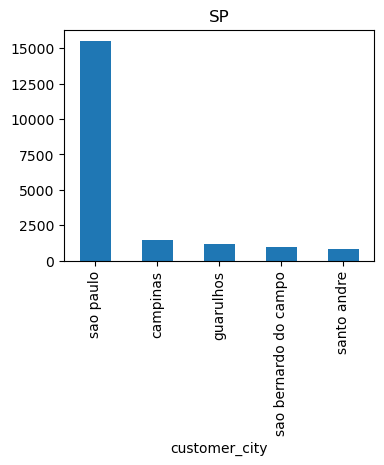

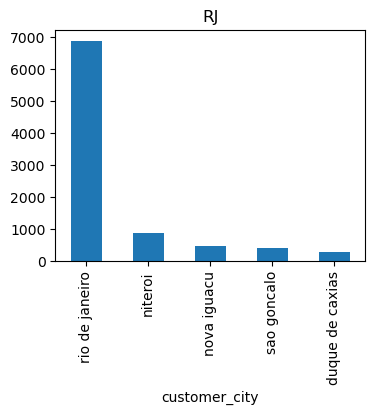

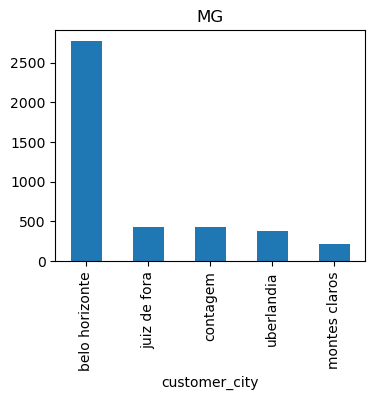

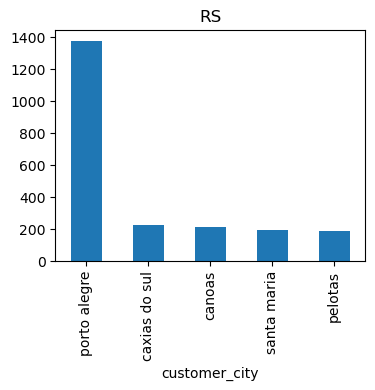

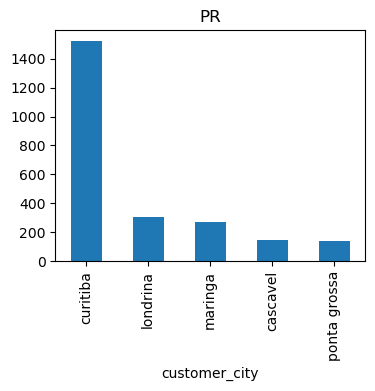

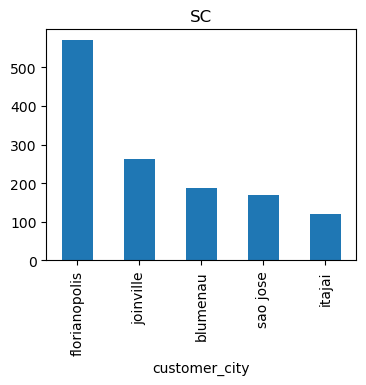

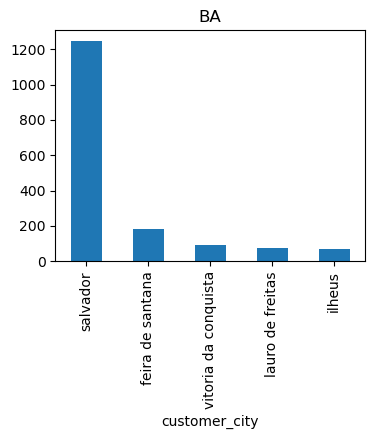

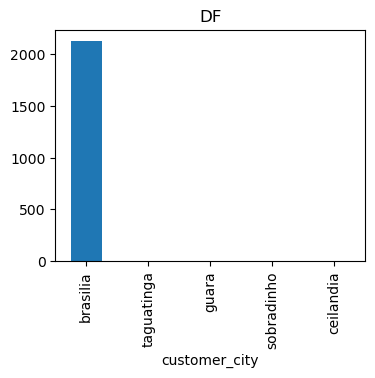

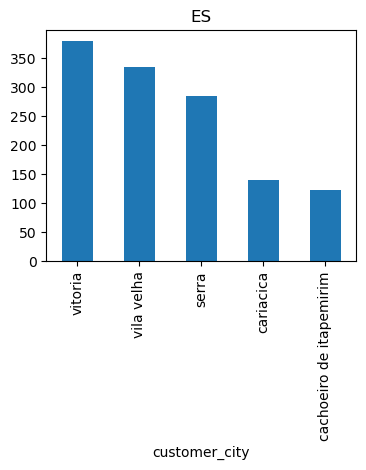

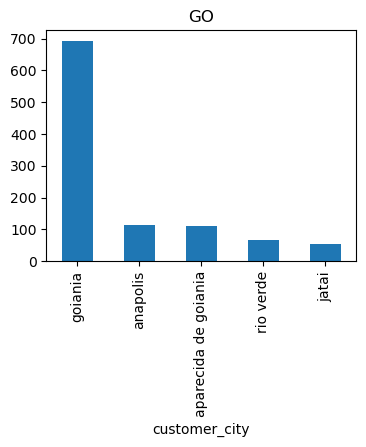

In [89]:
states_data = top_states['customer_state']
for items in states_data:
  print('')
  print(items)
  print('')
  print(df_customers[df_customers['customer_state'] == items]['customer_city'].value_counts().head(5))
  print('')

  plt.figure(figsize = (4,3))
  plt.title(items)
  df_customers[df_customers['customer_state'] == items]['customer_city'].value_counts().head(5).plot(kind = 'bar')
  print('')

### CONCLUSION ::

END OF CUSTOMER DATA ANALYSIS

### Analysing the Payment data 

In [13]:
df_payment.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [14]:
df_payment.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [15]:
df_payment.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
22783,89739437b72ddcc97ca62d9ce338d0fd,1,credit_card,2,127.05
94304,bfd223d76eb49674f6870a4ed53081b9,1,boleto,1,78.18
1344,b4059555399120834bc8cf54a84bc6c8,1,credit_card,1,26.77
25892,e2144124f98f3bf46939bc5183104041,1,credit_card,1,50.86
103407,c52fc1fc33756cfdee5d0cd6fed55765,1,credit_card,7,182.63


In [16]:
df_payment.duplicated().sum()

np.int64(0)

NO REPITITIVE VALUE

In [17]:
payment_mode = df_payment['payment_type'].value_counts()
payment_mode

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

#### PAYMENT MODE USED BY MAJORITY OF PEOPLE IS CREDIT CARD THEN BOLETO,VOUCHER,DEBIT CARD RESPECTIVELY

Text(0, 0.5, 'Value')

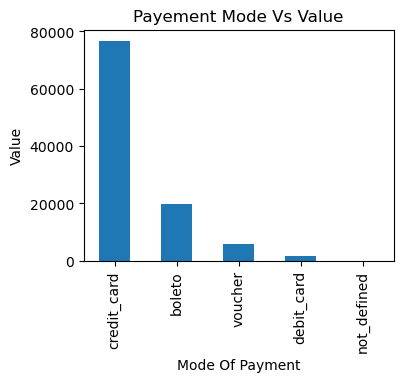

In [18]:
plt.figure(figsize=(4,3))
payment_mode.plot(kind = 'bar')
plt.title('Payement Mode Vs Value')
plt.xlabel('Mode Of Payment')
plt.ylabel('Value')

In [19]:
 df_payment.groupby('payment_type')[['payment_value','payment_installments']].describe()

payment_value                                                  \
                     count        mean         std    min      25%     50%   
payment_type                                                                 
boleto             19784.0  145.034435  213.581061  11.62  55.5225   93.89   
credit_card        76795.0  163.319021  222.119311   0.01  62.2100  106.87   
debit_card          1529.0  142.570170  245.793401  13.38  51.1000   89.30   
not_defined            3.0    0.000000    0.000000   0.00   0.0000    0.00   
voucher             5775.0   65.703354  115.519185   0.00  18.0350   39.28   

                                 payment_installments                          \
                   75%       max                count      mean      std  min   
payment_type                                                                    
boleto        160.7625   7274.88              19784.0  1.000000  0.00000  1.0   
credit_card   181.2100  13664.08              76795.0  3.507155  2.85099  0.0   
debit_card    154.3200   4445.50               1529.0  1.000000  0.00000  1.0   
not_defined     0.0000      0.00                  3.0  1.000000  0.00000  1.0   
voucher        80.0000   3184.34               5775.0  1.000000  0.00000  1.0   

                                   
              25%  50%  75%   max  
payment_type                       
boleto        1.0  1.0  1.0   1.0  
credit_card   1.0  3.0  5.0  24.0  
debit_card    1.0  1.0  1.0   1.0  
not_defined   1.0  1.0  1.0   1.0  
voucher       1.0  1.0  1.0   1.0

In [20]:
 df_payment.groupby('payment_type')[['payment_value','payment_installments']].mean()

,payment_value,payment_installments
payment_type,,
boleto,145.034435,1.000000
credit_card,163.319021,3.507155
debit_card,142.570170,1.000000
not_defined,0.000000,1.000000
voucher,65.703354,1.000000


### ORDERS DATA ANALYSIS

In [21]:

df_orders.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
35949,da205e39e5c9572ab09b0f2ee02e7c04,20a73b83014dca8ee7bfe6fc4a4692b0,delivered,2018-06-04 15:01:08,2018-06-05 04:31:15,2018-06-06 16:18:00,2018-06-20 18:04:10,2018-07-26 00:00:00
15178,765077a5aa4353d785afcdccc40cbfd9,ab1a448195bfd64f02c4114a20292032,delivered,2018-05-04 14:46:10,2018-05-04 15:10:04,2018-05-08 15:13:00,2018-05-14 16:43:44,2018-05-23 00:00:00
16253,ad366003d331bb0eaa77c1efc5570657,d54371af4fe03138c67f7ad33c8986f2,delivered,2018-01-17 08:03:08,2018-01-18 02:11:30,2018-01-18 18:34:56,2018-01-22 21:23:03,2018-02-07 00:00:00
6210,3276afbd4fd6d9c1909717750fd3135e,f0d2b8ae25840fa9bc09e6a4288dea1e,delivered,2018-07-02 20:34:51,2018-07-02 20:50:17,2018-07-03 14:35:00,2018-07-09 18:46:37,2018-08-07 00:00:00
38579,93d3acc57bd28d53e25e2624c13c470d,d472dbf6ecbea44dbc6078d5bb5c0c6d,delivered,2018-05-21 11:06:07,2018-05-23 02:55:12,2018-05-23 11:20:00,2018-06-01 20:51:58,2018-06-05 00:00:00


In [22]:
df_orders['order_status'].value_counts() / df_orders.shape[0] * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: count, dtype: float64

#### 1. In this 97% of delivery rate.
#### 2. And 0.62% of cancelled rate.
 It showing good efficiency.

In [23]:
df_products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [24]:
df_orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [25]:
df_orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [26]:
df_products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [27]:
df_products['product_category_name'].nunique()

73

In [28]:
# Total 73 unique product category 
df_products['product_id'].nunique()

32951

In [29]:
df_products.shape

(32951, 9)

#### Here product_id showing kind off product name 

In [30]:
df_order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [31]:
df_order_items.shape

(112650, 7)

In [32]:
df_products.shape

(32951, 9)

In [33]:
df_products.duplicated().sum() 

np.int64(0)

#### All the products have unique product_id ( Primary Key )

In [34]:
df_order_items['product_id'].nunique()

32951

In [35]:
## we can see that all the products got ordered it is a good plus point

In [36]:
df_order_items.shape

(112650, 7)

In [37]:
df_order_items['order_id'].nunique()

98666

In [38]:
freq_ordered_product = df_order_items.groupby('product_id')['order_id'].count().sort_values(ascending=False).reset_index()

In [39]:
freq_ordered_product.rename(columns={'order_id':'frequency'} , inplace= True)

In [131]:
# products ordered for the most of the time
freq_ordered_product

,product_id,frequency
0,aca2eb7d00ea1a7b8ebd4e68314663af,527
1,99a4788cb24856965c36a24e339b6058,488
2,422879e10f46682990de24d770e7f83d,484
3,389d119b48cf3043d311335e499d9c6b,392
4,368c6c730842d78016ad823897a372db,388
...,...,...
32946,ffd7628b0b0b98ebc549e8e4c54a59af,1
32947,ffd63ee42a5c8cc5a15a1c8e2aa50011,1
32948,002959d7a0b0990fe2d69988affcbc80,1
32949,002552c0663708129c0019cc97552d7d,1


In [132]:
tf = freq_ordered_product.merge(df_products , on = 'product_id')[['product_id','frequency','product_category_name']].merge(df_product_category , on = 'product_category_name')[['product_id','product_category_name_english','frequency']]


In [133]:
tf.sort_values(
    by=['frequency', 'product_category_name_english'],
    ascending=[False, True],
    inplace=True
)

In [134]:
tf['frequency'].sum()

np.int64(111023)

In [138]:
tf.head(10)

# it is showing top 10 products with most ordered count vs its ordered count

,product_id,product_category_name_english,frequency
0,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,527
1,99a4788cb24856965c36a24e339b6058,bed_bath_table,488
2,422879e10f46682990de24d770e7f83d,garden_tools,484
3,389d119b48cf3043d311335e499d9c6b,garden_tools,392
4,368c6c730842d78016ad823897a372db,garden_tools,388
5,53759a2ecddad2bb87a079a1f1519f73,garden_tools,373
6,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,343
7,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,323
8,154e7e31ebfa092203795c972e5804a6,health_beauty,281
9,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,274


<Axes: xlabel='product_category_name_english'>

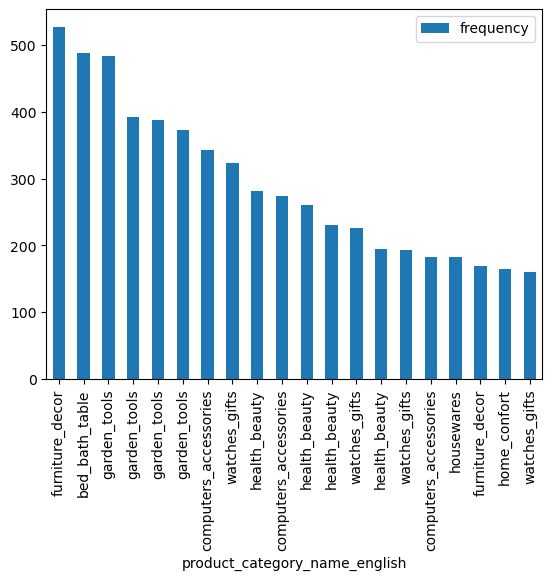

In [140]:
tf.head(20).plot(kind='bar', x='product_category_name_english', y='frequency')

In [139]:
tf.shape

(32328, 3)

In [142]:
tf.tail(20)

# it is showing products with less number of orders vs its order count

,product_id,product_category_name_english,frequency
31855,fc35f167625d74f06ad5e5e643172cb9,watches_gifts,1
31865,fc4e529d4121c3f5ced63c2ad05fb2d2,watches_gifts,1
31899,fc86606232e0da421bf450a13068a4b4,watches_gifts,1
31930,fcd0a70961c103799897803f4e49c628,watches_gifts,1
31966,fd06ee724785658f80f21107c42352a8,watches_gifts,1
31981,fd12e3863702114b037de431a73ed139,watches_gifts,1
32001,02090f97a28b3d10d19a09f045f6df34,watches_gifts,1
32062,fdc7b4c1ee3b0ba0c649a3147d039983,watches_gifts,1
32090,fe02ad514379012c6a31b62741a3a9d4,watches_gifts,1
32108,017e3ffa31fcd2f8061fa66a9e486381,watches_gifts,1


<Axes: xlabel='product_category_name_english'>

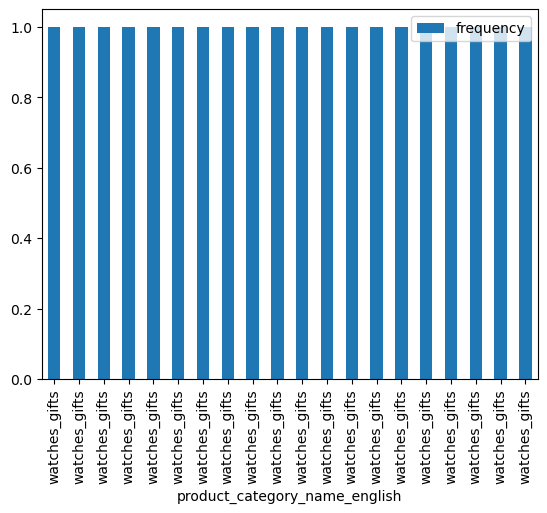

In [143]:
tf.tail(20).plot(kind='bar', x='product_category_name_english', y='frequency')

In [50]:
df_order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [51]:
tf1 = df_order_items.merge(df_products , on = 'product_id')[['product_id','product_category_name']].merge(df_product_category , on = 'product_category_name')[['product_id','product_category_name_english']]


In [52]:
tf1.rename(columns = {'product_category_name_english' : 'product_category'} , inplace= True)

In [53]:
tf1

,product_id,product_category
0,4244733e06e7ecb4970a6e2683c13e61,cool_stuff
1,e5f2d52b802189ee658865ca93d83a8f,pet_shop
2,c777355d18b72b67abbeef9df44fd0fd,furniture_decor
3,7634da152a4610f1595efa32f14722fc,perfumery
4,ac6c3623068f30de03045865e4e10089,garden_tools
...,...,...
111018,4aa6014eceb682077f9dc4bffebc05b0,housewares
111019,32e07fd915822b0765e448c4dd74c828,computers_accessories
111020,72a30483855e2eafc67aee5dc2560482,sports_leisure
111021,9c422a519119dcad7575db5af1ba540e,computers_accessories


In [54]:
tf1_new = tf1.groupby('product_category')['product_id'].count().reset_index().rename(columns = {'product_id': 'frequency'}).sort_values(by = ['frequency','product_category'],ascending = [False , True])

In [55]:
tf1_new

,product_category,frequency
7,bed_bath_table,11115
43,health_beauty,9670
65,sports_leisure,8641
39,furniture_decor,8334
15,computers_accessories,7827
...,...,...
3,arts_and_craftmanship,24
11,cds_dvds_musicals,14
52,la_cuisine,14
29,fashion_childrens_clothes,8


In [56]:
# Top 20 Most Selling product category
tf1_new.head(20)

,product_category,frequency
7,bed_bath_table,11115
43,health_beauty,9670
65,sports_leisure,8641
39,furniture_decor,8334
15,computers_accessories,7827
49,housewares,6964
70,watches_gifts,5991
68,telephony,4545
42,garden_tools,4347
5,auto,4235


Text(0.5, 1.0, 'product_categoey VS frequency')

<Figure size 400x300 with 0 Axes>

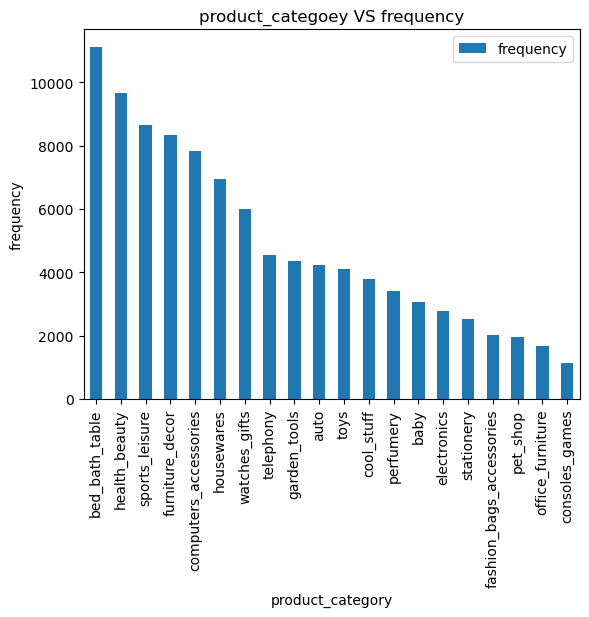

In [57]:
plt.figure(figsize= (4,3))
tf1_new.head(20).plot(kind = 'bar' ,x = 'product_category',y = 'frequency')
plt.xlabel('product_category')
plt.ylabel('frequency')
plt.title('product_categoey VS frequency')

In [90]:
# Least selling product category
tf1_new.tail(20)

,product_category,frequency
38,furniture_bedroom,109
22,costruction_tools_tools,103
67,tablets_printing_image,83
64,small_appliances_home_oven_and_coffee,76
13,cine_photo,72
25,dvds_blu_ray,64
9,books_imported,60
27,fashio_female_clothing,48
58,party_supplies,43
23,diapers_and_hygiene,39


Text(0.5, 1.0, 'product_categoey VS frequency')

<Figure size 400x300 with 0 Axes>

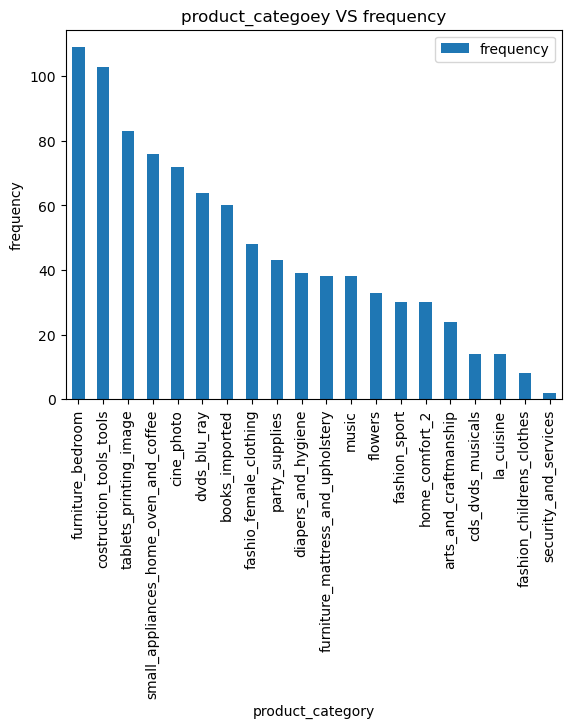

In [59]:
plt.figure(figsize= (4,3))
tf1_new.tail(20).plot(kind = 'bar' ,x = 'product_category',y = 'frequency')
plt.xlabel('product_category')
plt.ylabel('frequency')
plt.title('product_categoey VS frequency')

### Analysing the review data OR Analysing the Customer Feedback towards the product 

In [60]:
df_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [91]:
df_reviews.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [62]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [63]:
df_order_delivered = df_orders[df_orders['order_status'] == 'delivered']
df_order_notdelivered = df_orders[~(df_orders['order_status'] == 'delivered')]

In [64]:
df_order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [65]:
df_reviews.merge(df_order_delivered,on = 'order_id')[['order_id','review_score']]

,order_id,review_score
0,73fc7af87114b39712e6da79b0a377eb,4
1,a548910a1c6147796b98fdf73dbeba33,5
2,f9e4b658b201a9f2ecdecbb34bed034b,5
3,658677c97b385a9be170737859d3511b,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,5
...,...,...
96356,2a8c23fee101d4d5662fa670396eb8da,5
96357,22ec9f0669f784db00fa86d035cf8602,5
96358,55d4004744368f5571d1f590031933e4,5
96359,7725825d039fc1f0ceb7635e3f7d9206,4


In [66]:
df_reviews.merge(df_order_notdelivered,on = 'order_id')['order_status'].value_counts()

order_status
shipped        1043
canceled        609
unavailable     597
invoiced        313
processing      296
created           3
approved          2
Name: count, dtype: int64

In [70]:
df_products_new = df_products.merge(df_product_category , on = 'product_category_name')[['product_id','product_category_name_english', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm']].rename(columns = {'product_category_name_english':'product_category'})

In [69]:
df_products_new

,product_id,product_category,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32323,a0b7d5a992ccda646f2d34e418fff5a0,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32324,bf4538d88321d0fd4412a93c974510e6,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32325,9a7c6041fa9592d9d9ef6cfe62a71f8c,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32326,83808703fc0706a22e264b9d75f04a2e,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [71]:
df_review_anl = df_reviews.merge(df_order_delivered,on = 'order_id')[['order_id','review_score']].merge(df_order_items , on = 'order_id')[['order_id','review_score','product_id']].merge(df_products_new, on = 'product_id')[['order_id','review_score','product_id','product_category']]

In [72]:
df_review_anl

,order_id,review_score,product_id,product_category
0,73fc7af87114b39712e6da79b0a377eb,4,fd25ab760bfbba13c198fa3b4f1a0cd3,sports_leisure
1,73fc7af87114b39712e6da79b0a377eb,4,fd25ab760bfbba13c198fa3b4f1a0cd3,sports_leisure
2,a548910a1c6147796b98fdf73dbeba33,5,be0dbdc3d67d55727a65d4cd696ca73c,computers_accessories
3,f9e4b658b201a9f2ecdecbb34bed034b,5,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories
4,658677c97b385a9be170737859d3511b,5,52c80cedd4e90108bf4fa6a206ef6b03,garden_tools
...,...,...,...,...
108453,2a8c23fee101d4d5662fa670396eb8da,5,4fb209073dc2ab6a6d3c259a7c285501,furniture_decor
108454,22ec9f0669f784db00fa86d035cf8602,5,3a33c980b62eb1ef3b8ae61b6fc6fe55,toys
108455,55d4004744368f5571d1f590031933e4,5,8ba0118a487ec8671aed57e5ef846574,stationery
108456,7725825d039fc1f0ceb7635e3f7d9206,4,73a7fbf8c1048131f3b531af31bcdf0e,sports_leisure


In [73]:
df_category_review = round(df_review_anl.groupby('product_category')['review_score'].mean(),2).reset_index().sort_values(by = ['review_score','product_category'] , ascending = [False,True]).rename(columns = {'review_score':'average_review_score'})

In [145]:
# best 10 product category by customer feedback ( PRODUCT CATEGORY LIKED MOST BY CUSTOMER )

df_category_review.head(10)

,product_category,average_review_score
29,fashion_childrens_clothes,5.00
11,cds_dvds_musicals,4.64
8,books_general_interest,4.51
9,books_imported,4.51
22,costruction_tools_tools,4.44
64,small_appliances_home_oven_and_coffee,4.44
35,flowers,4.42
10,books_technical,4.39
32,fashion_sport,4.37
37,food_drink,4.37


<Axes: xlabel='product_category'>

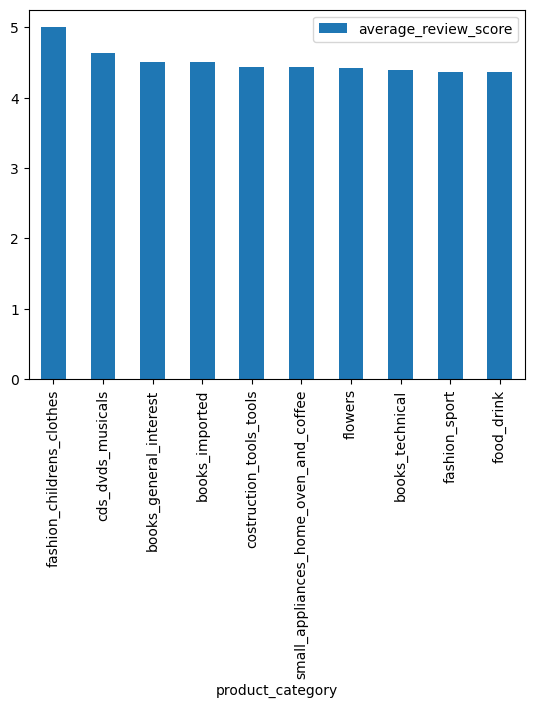

In [146]:
# most liked product category by users

# Barplot of most liked product category
df_category_review.head(10).plot(kind = 'bar' , x ='product_category' , y = 'average_review_score' )

In [147]:
# worst product category ( by customer feedback ) OR MOST DISLIKED PRODUCT CATEGORY 

df_category_review.tail(10)

,product_category,average_review_score
41,furniture_mattress_and_upholstery,3.89
47,home_confort,3.85
4,audio,3.83
58,party_supplies,3.83
30,fashion_male_clothing,3.76
34,fixed_telephony,3.76
46,home_comfort_2,3.63
57,office_furniture,3.52
23,diapers_and_hygiene,3.38
61,security_and_services,2.50


<Axes: xlabel='product_category'>

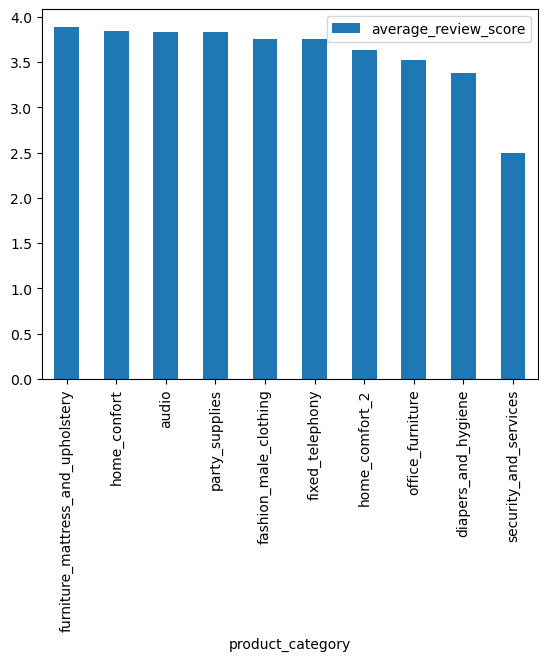

In [148]:
# MOST DISLIKED PRODUCT CATEGORY (ACCORDING TO REVIEW SCORE GIVEN BY CUSTOMER )

# Barplot of most liked product category
df_category_review.tail(10).plot(kind = 'bar' , x ='product_category' , y = 'average_review_score' )

In [149]:
df_order_notdelivered.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00


In [80]:
df_order_delivered['order_purchase_timestamp'] = pd.to_datetime(
    df_order_delivered['order_purchase_timestamp']
)
df_order_delivered['days_to_deliver'] = (pd.to_datetime(df_order_delivered['order_delivered_customer_date']) - pd.to_datetime(df_order_delivered['order_purchase_timestamp'])).dt.days
df_order_delivered['estimeted_delivery_days'] = (pd.to_datetime(df_order_delivered['order_estimated_delivery_date']) - pd.to_datetime(df_order_delivered['order_approved_at'])).dt.days

In [151]:
# DATA OF DELIVERED PRODUCT IN WHICH DELIVERY TIME IS GREATER THAN THE ESTIMATED TIME

df_order_delivered[df_order_delivered['days_to_deliver'] > df_order_delivered['estimeted_delivery_days']].shape

(8212, 10)

In [156]:
# Here 8212 such rows in which delivery time is greater than the estimated time
# Problem is that, this is 8 percent of total data.

In [84]:
# percent of orders delivered late than estimated period
(8000 / 100000) * 100 

8.0

In [83]:
df_customers['customer_city'].nunique()

4119

In [105]:
worst_data = df_customers.merge(df_order_delivered[df_order_delivered['days_to_deliver'] > df_order_delivered['estimeted_delivery_days']] , on = 'customer_id')['customer_city'].value_counts().head(10)
worst_data

customer_city
sao paulo         1021
rio de janeiro     796
salvador           213
belo horizonte     170
porto alegre       165
brasilia           155
campinas           152
fortaleza          118
niteroi            104
sao goncalo         93
Name: count, dtype: int64

<Axes: xlabel='customer_city'>

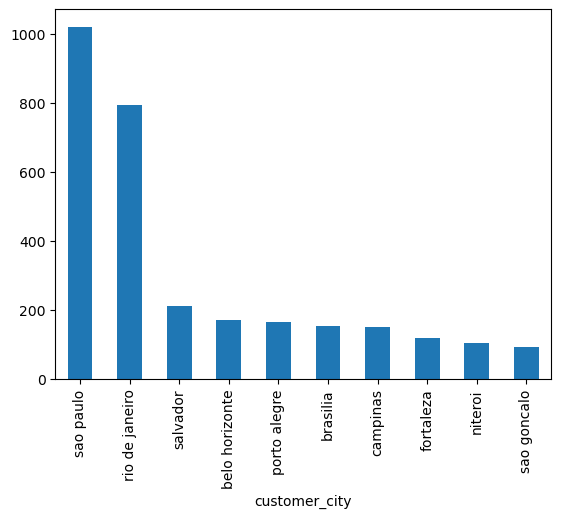

In [107]:
worst_data.plot(kind = 'bar')

In [157]:
df_customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [158]:
# No. of unique cities in which delivery time is greter than the estimated time 

df_customers.merge(df_order_delivered[df_order_delivered['days_to_deliver'] > df_order_delivered['estimeted_delivery_days']] , on = 'customer_id')['customer_city'].nunique()

1359

In [110]:
df_geolocation.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [111]:
df_sellers.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [159]:
# Average delivery time across all category

round(df_order_delivered['days_to_deliver'].mean(),2)

np.float64(12.09)

In [161]:
# Average delivery time across all category is 12 days 

delivery_per_category = df_order_delivered.merge(df_order_items, on = 'order_id')[['product_id','days_to_deliver','estimeted_delivery_days']].merge(df_products_new,on = 'product_id')[['product_category','days_to_deliver','estimeted_delivery_days']]
delivery_per_category.head(10)

,product_category,days_to_deliver,estimeted_delivery_days
0,housewares,8.0,15.0
1,perfumery,13.0,17.0
2,auto,9.0,26.0
3,pet_shop,13.0,26.0
4,stationery,2.0,12.0
5,auto,16.0,22.0
6,auto,9.0,21.0
7,furniture_decor,9.0,39.0
8,office_furniture,18.0,24.0
9,garden_tools,12.0,21.0


In [122]:
dpc1 = round(delivery_per_category.groupby('product_category')[['days_to_deliver','estimeted_delivery_days']].mean(),0)

In [163]:
# sorting the values by decreasing no. of delivery days 

dpc1.sort_values(by = 'days_to_deliver', ascending=False,inplace=True)

In [164]:
# Product class takes larger time to deliver the product

dpc1.head(20)

,days_to_deliver,estimeted_delivery_days
product_category,,
office_furniture,20.0,31.0
christmas_supplies,15.0,26.0
security_and_services,15.0,30.0
fashion_shoes,15.0,29.0
home_comfort_2,14.0,22.0
furniture_mattress_and_upholstery,14.0,20.0
audio,13.0,22.0
musical_instruments,13.0,23.0
home_construction,13.0,23.0


<Axes: xlabel='product_category'>

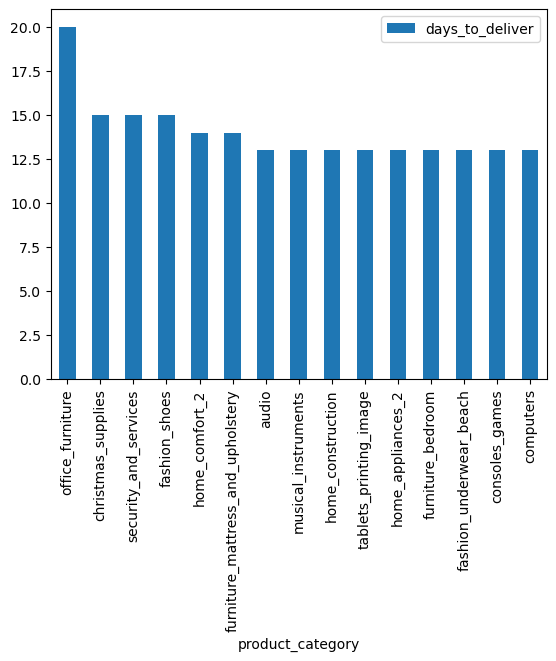

In [165]:
# plotting of top product category by taking most days to deliver the product 

dpc1.head(15).plot(kind = 'bar',y = 'days_to_deliver')

In [167]:
# Product class takes least time to deliver the product

dpc1.tail(10)

,days_to_deliver,estimeted_delivery_days
product_category,,
diapers_and_hygiene,10.0,21.0
food_drink,10.0,21.0
small_appliances_home_oven_and_coffee,9.0,20.0
party_supplies,9.0,23.0
construction_tools_lights,9.0,19.0
food,9.0,18.0
fashion_childrens_clothes,8.0,23.0
books_imported,8.0,18.0
la_cuisine,7.0,23.0


Text(0.5, 1.0, 'Product_category VS Average Delivery Time ')

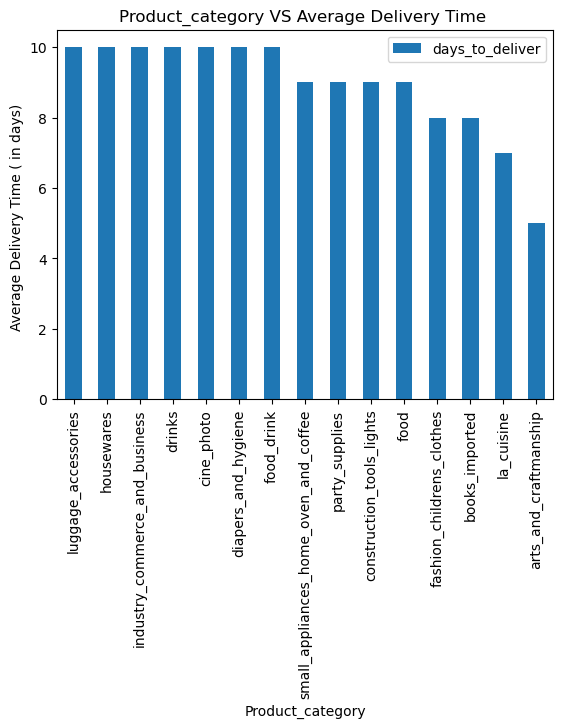

In [169]:
# Plotting of product category takes least time to deliver the product

dpc1.tail(15).plot(kind = 'bar',y = 'days_to_deliver')
plt.xlabel('Product_category')
plt.ylabel('Average Delivery Time ( in days) ')
plt.title('Product_category VS Average Delivery Time ')


In [175]:
seller_analysis_data = df_order_items.merge(df_sellers ,on = 'seller_id')[['order_id','product_id','seller_id','price','freight_value','seller_city','seller_state']]
seller_analysis_data

,order_id,product_id,seller_id,price,freight_value,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,loanda,PR
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,299.99,43.41,itajai,SC
112646,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,350.00,36.53,sao paulo,SP
112647,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,99.90,16.95,curitiba,PR
112648,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,55.99,8.72,sao paulo,SP


In [178]:
seller_analysis_data.groupby('seller_city')['seller_id'].count().sort_values(ascending = False).head(20)

seller_city
sao paulo                27983
ibitinga                  7750
curitiba                  3016
santo andre               2964
belo horizonte            2593
sao jose do rio preto     2579
rio de janeiro            2442
guarulhos                 2362
ribeirao preto            2269
maringa                   2220
piracicaba                1903
itaquaquecetuba           1653
campinas                  1430
salto                     1346
praia grande              1333
campo limpo paulista      1195
guariba                   1156
sao bernardo do campo     1125
jacarei                    954
limeira                    933
Name: seller_id, dtype: int64

Text(0.5, 1.0, 'City Name VS No. Of Sellers ')

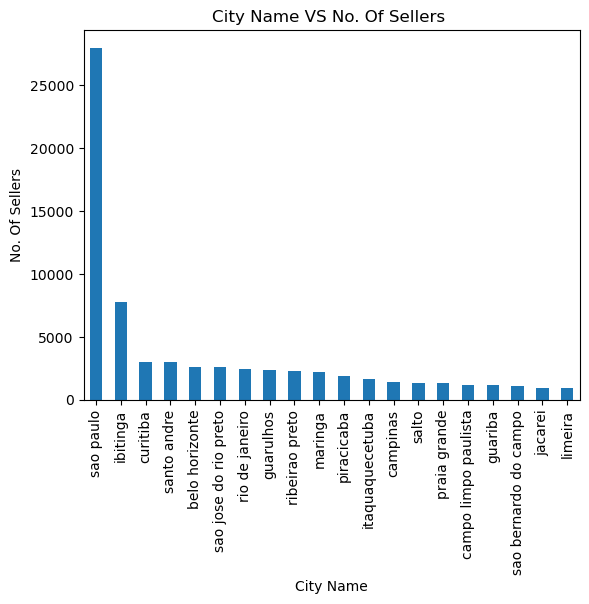

In [203]:
# Cities with the highest number of sellers

seller_analysis_data.groupby('seller_city')['seller_id'].count().sort_values(ascending = False).head(20).plot(kind = 'bar')
plt.xlabel('City Name')
plt.ylabel('No. Of Sellers')
plt.title('City Name VS No. Of Sellers ')

In [182]:
# Cities with the highest number of sellers
seller_analysis_data.groupby('seller_city')['seller_id'].count().sort_values(ascending = False).head(20)

seller_city
sao paulo                27983
ibitinga                  7750
curitiba                  3016
santo andre               2964
belo horizonte            2593
sao jose do rio preto     2579
rio de janeiro            2442
guarulhos                 2362
ribeirao preto            2269
maringa                   2220
piracicaba                1903
itaquaquecetuba           1653
campinas                  1430
salto                     1346
praia grande              1333
campo limpo paulista      1195
guariba                   1156
sao bernardo do campo     1125
jacarei                    954
limeira                    933
Name: seller_id, dtype: int64

Text(0.5, 1.0, 'City Name VS No. Of Sellers ')

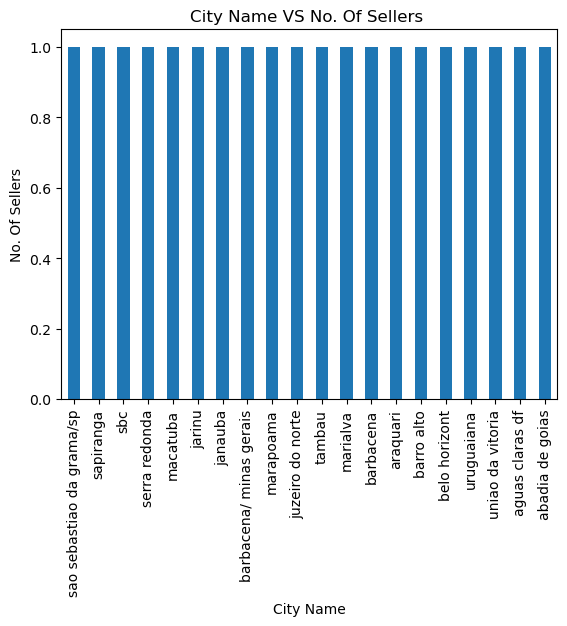

In [183]:
# Plot of Cities with the highest number of sellers

seller_analysis_data.groupby('seller_city')['seller_id'].count().sort_values(ascending = False).tail(20).plot(kind = 'bar')
plt.xlabel('City Name')
plt.ylabel('No. Of Sellers')
plt.title('City Name VS No. Of Sellers ')

In [191]:
# Product category with its average unit cost 

product_avg_cost = df_products_new.merge(seller_analysis_data , on = 'product_id')[['product_category','price']].groupby('product_category')['price'].mean().reset_index() 
product_avg_cost

,product_category,price
0,agro_industry_and_commerce,342.124858
1,air_conditioning,185.269226
2,art,115.802105
3,arts_and_craftmanship,75.583750
4,audio,139.254121
...,...,...
66,stationery,91.753369
67,tablets_printing_image,90.703735
68,telephony,71.213978
69,toys,117.548360


In [196]:
# Top 15 Product category those have highest average unit cost 

product_avg_cost.sort_values(by = 'price' , ascending = False).head(15)

,product_category,price
14,computers,1098.340542
64,small_appliances_home_oven_and_coffee,624.285658
45,home_appliances_2,476.124958
0,agro_industry_and_commerce,342.124858
56,musical_instruments,281.616000
63,small_appliances,280.778468
34,fixed_telephony,225.693182
19,construction_tools_safety,208.992371
70,watches_gifts,201.135984
1,air_conditioning,185.269226


Text(0.5, 1.0, 'Product_Category VS Average Unit Cost ')

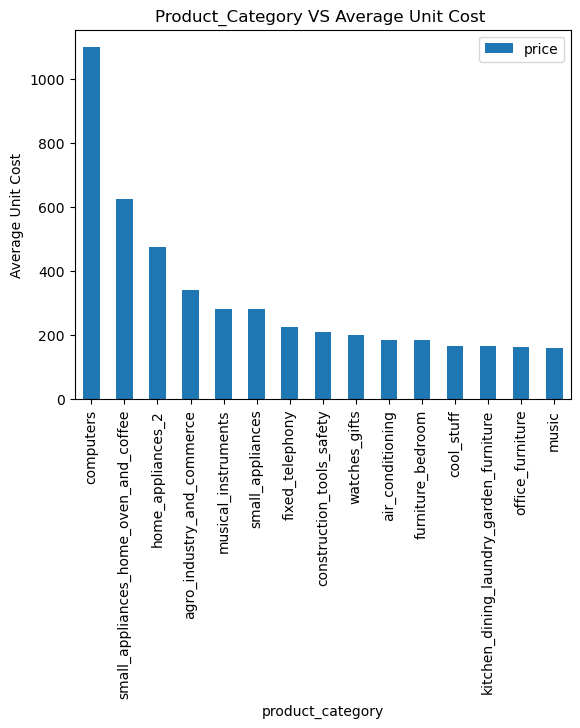

In [201]:
product_avg_cost.sort_values(by = 'price' , ascending = False).head(15).plot(kind = 'bar' , x = 'product_category')
plt.xlabel('product_category')
plt.ylabel('Average Unit Cost')
plt.title('Product_Category VS Average Unit Cost ')

In [198]:
# Top 15 Product category those have least average unit cost 

product_avg_cost.sort_values(by = 'price' , ascending = False).tail(15)

,product_category,price
33,fashion_underwear_beach,72.836260
10,books_technical,71.520824
29,fashion_childrens_clothes,71.231250
68,telephony,71.213978
32,fashion_sport,70.650333
24,drinks,59.178628
27,fashio_female_clothing,58.409167
26,electronics,57.913531
36,food,57.634137
12,christmas_supplies,57.521699


Text(0.5, 1.0, 'Product_Category VS Average Unit Cost ')

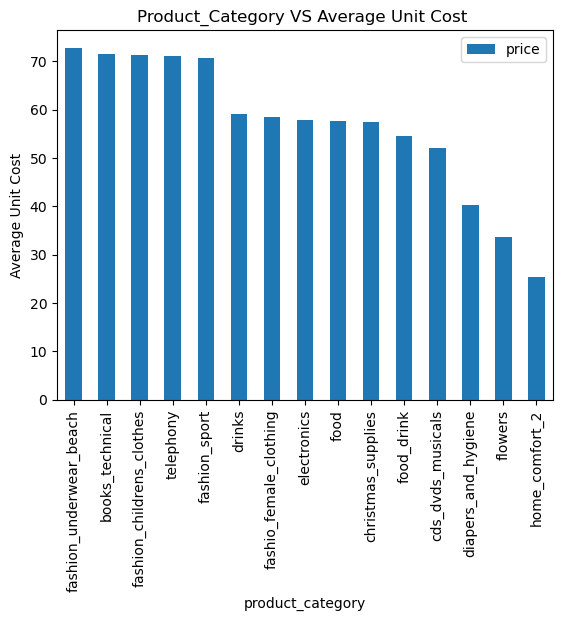

In [202]:
# Top 15 Product category those have least average unit cost 

product_avg_cost.sort_values(by = 'price' , ascending = False).tail(15).plot(kind = 'bar' , x = 'product_category')
plt.xlabel('product_category')
plt.ylabel('Average Unit Cost')
plt.title('Product_Category VS Average Unit Cost ')